In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#read in the data
df = pd.read_csv('data.csv')

df.head()

,Deal ID,Company ID,Company Name,Description,Investor ID,Investor Name,Investor Website,Investor Status,Primary Investor Type,Other Investor Types,...,Valuation/Cash Flow,Deal Status,Primary Industry Sector,Primary Industry Group,Primary Industry Code,Verticals,All Industries,Business Status,Financing Status,PitchBook Link
0,249733-63T,464342-95,Flowdesk,Developer of a compliant trading and liquidity...,187980-13,Cathay Innovation,www.cathayinnovation.com,Active Investor,Venture Capital,NaN,...,NaN,Completed,Information Technology,Software,Financial Software,"Cryptocurrency/Blockchain, FinTech",Financial Software*; Other Financial Services,Generating Revenue,Venture Capital-Backed,NaN
1,249733-63T,464342-95,Flowdesk,Developer of a compliant trading and liquidity...,11180-08,Eurazeo,www.eurazeo.com,Active Investor,PE/Buyout,"Growth/Expansion, Infrastructure, Venture Capital",...,NaN,Completed,Information Technology,Software,Financial Software,"Cryptocurrency/Blockchain, FinTech",Financial Software*; Other Financial Services,Generating Revenue,Venture Capital-Backed,NaN
2,249733-63T,464342-95,Flowdesk,Developer of a compliant trading and liquidity...,51189-94,HV Capital,www.hvcapital.com,Active Investor,Venture Capital,Growth/Expansion,...,NaN,Completed,Information Technology,Software,Financial Software,"Cryptocurrency/Blockchain, FinTech",Financial Software*; Other Financial Services,Generating Revenue,Venture Capital-Backed,NaN
3,272893-60T,530537-68,Wavo (Financial Software),Developer of a financial platform designed to ...,434507-50,Tony Parker,NaN,Active Investor,Angel (individual),NaN,...,NaN,Completed,Information Technology,Software,Financial Software,"Artificial Intelligence & Machine Learning, Fi...",Financial Software*; Other Financial Services,Generating Revenue,Venture Capital-Backed,NaN
4,285052-87T,512410-51,Smile Wanted Group,Operator of a digital advertising marketplace ...,58004-02,Bpifrance,www.bpifrance.fr,Active Investor,Sovereign Wealth Fund,"Accelerator/Incubator, Fund of Funds, Growth/E...",...,NaN,Completed,Business Products and Services (B2B),Commercial Services,Media and Information Services (B2B),"AdTech, Marketing Tech",Media and Information Services (B2B)*; Other C...,Generating Revenue,Venture Capital-Backed,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8147 entries, 0 to 8146
Data columns (total 62 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Deal ID                                     8147 non-null   object 
 1   Company ID                                  8147 non-null   object 
 2   Company Name                                8147 non-null   object 
 3   Description                                 8147 non-null   object 
 4   Investor ID                                 8147 non-null   object 
 5   Investor Name                               8147 non-null   object 
 6   Investor Website                            5469 non-null   object 
 7   Investor Status                             8147 non-null   object 
 8   Primary Investor Type                       8147 non-null   object 
 9   Other Investor Types                        3744 non-null   object 
 10  Preferred In

In [5]:
# Calculate the threshold for 80% null values
threshold = len(df) * 0.8

# Drop columns with more than 80% null values
df = df.dropna(thresh=threshold, axis=1)

df.head()

,Deal ID,Company ID,Company Name,Description,Investor ID,Investor Name,Investor Status,Primary Investor Type,Preferred Industries,Investor HQ,...,Company Post Code,Company Country/Territory,Deal Status,Primary Industry Sector,Primary Industry Group,Primary Industry Code,Verticals,All Industries,Business Status,Financing Status
0,249733-63T,464342-95,Flowdesk,Developer of a compliant trading and liquidity...,187980-13,Cathay Innovation,Active Investor,Venture Capital,"Commercial Transportation, Healthcare Devices ...","San Francisco, CA",...,75001.0,France,Completed,Information Technology,Software,Financial Software,"Cryptocurrency/Blockchain, FinTech",Financial Software*; Other Financial Services,Generating Revenue,Venture Capital-Backed
1,249733-63T,464342-95,Flowdesk,Developer of a compliant trading and liquidity...,11180-08,Eurazeo,Active Investor,PE/Buyout,"Commercial Services, Consumer Non-Durables, En...","Paris, France",...,75001.0,France,Completed,Information Technology,Software,Financial Software,"Cryptocurrency/Blockchain, FinTech",Financial Software*; Other Financial Services,Generating Revenue,Venture Capital-Backed
2,249733-63T,464342-95,Flowdesk,Developer of a compliant trading and liquidity...,51189-94,HV Capital,Active Investor,Venture Capital,"Consumer Non-Durables, Education and Training ...","Munich, Germany",...,75001.0,France,Completed,Information Technology,Software,Financial Software,"Cryptocurrency/Blockchain, FinTech",Financial Software*; Other Financial Services,Generating Revenue,Venture Capital-Backed
3,272893-60T,530537-68,Wavo (Financial Software),Developer of a financial platform designed to ...,434507-50,Tony Parker,Active Investor,Angel (individual),NaN,NaN,...,69003.0,France,Completed,Information Technology,Software,Financial Software,"Artificial Intelligence & Machine Learning, Fi...",Financial Software*; Other Financial Services,Generating Revenue,Venture Capital-Backed
4,285052-87T,512410-51,Smile Wanted Group,Operator of a digital advertising marketplace ...,58004-02,Bpifrance,Active Investor,Sovereign Wealth Fund,"Apparel and Accessories, Commercial Products, ...","Paris, France",...,75008.0,France,Completed,Business Products and Services (B2B),Commercial Services,Media and Information Services (B2B),"AdTech, Marketing Tech",Media and Information Services (B2B)*; Other C...,Generating Revenue,Venture Capital-Backed


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8147 entries, 0 to 8146
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Deal ID                         8147 non-null   object 
 1   Company ID                      8147 non-null   object 
 2   Company Name                    8147 non-null   object 
 3   Description                     8147 non-null   object 
 4   Investor ID                     8147 non-null   object 
 5   Investor Name                   8147 non-null   object 
 6   Investor Status                 8147 non-null   object 
 7   Primary Investor Type           8147 non-null   object 
 8   Preferred Industries            6834 non-null   object 
 9   Investor HQ                     7015 non-null   object 
 10  Lead Partner                    8147 non-null   object 
 11  Lead/Sole                       8147 non-null   object 
 12  Deal No.                        81

In [7]:
df['Primary Industry Sector'].unique()

array(['Information Technology', 'Business Products and Services (B2B)',
       'Healthcare', 'Consumer Products and Services (B2C)', 'Energy',
       'Financial Services', 'Materials and Resources'], dtype=object)

In [7]:
#Possible Categories to analyze
df['Investor Status'].unique()
df['Primary Investor Type'].unique()
df['Lead/Sole'].unique()
df['Deal Type 1'].unique()
df['Deal Class'].unique()
df['Deal Status'].unique()
df['Primary Industry Sector'].unique()
df['Business Status'].unique()
df['Financing Status'].unique()


array(['Venture Capital-Backed', 'Pending Transaction (VC)', nan,
       'Failed Transaction (VC)', 'Private Equity-Backed', 'Angel-Backed',
       'Accelerator/Incubator Backed', 'Private Debt Financed',
       'Formerly VC-Backed', 'Corporate Backed or Acquired'], dtype=object)

In [8]:
# Count the occurrences of each unique value in 'Lead Partner'
lead_partner_counts = df['Lead Partner'].value_counts()

# Display the top 10 most frequent Lead Partners
lead_partner_counts.head(10)

Lead Partner
Xavier Niel                 99
Thibaud Elziere             41
Guillaume Aubin             41
Joséphine Marie             33
Pierre Kosciusko Morizet    30
Jean-David Chamboredon      28
Philippe Collombel          25
Rodolphe Menegaux           24
Chahra Louafi               24
Romain Lavault              24
Name: count, dtype: int64

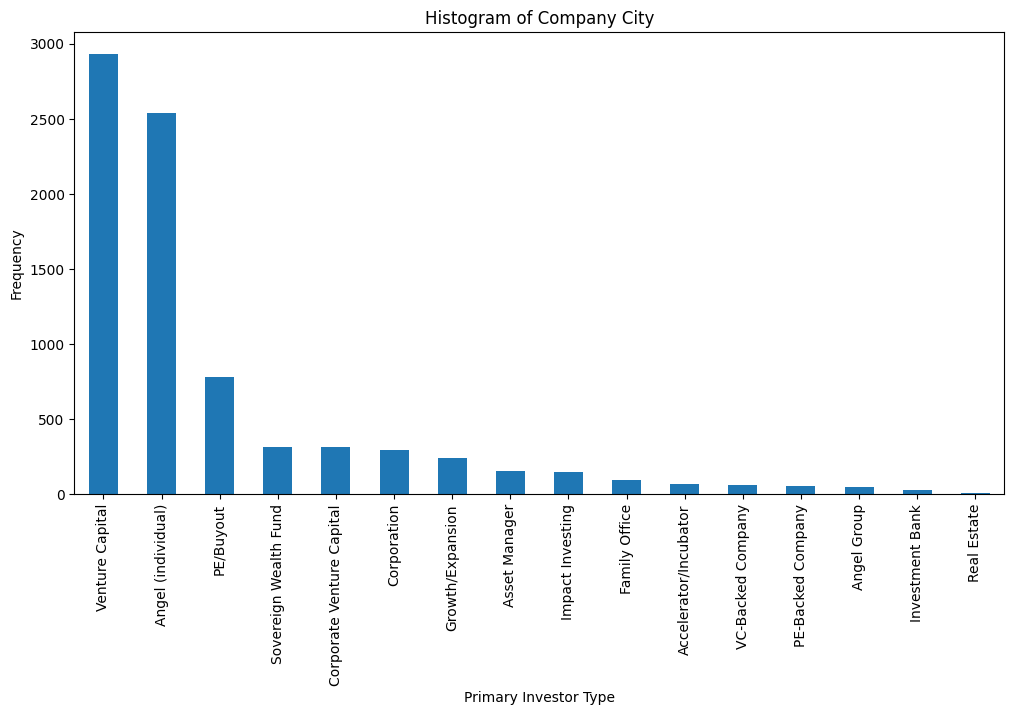

In [8]:
# Count the occurrences of each unique value in 'Company City'
company_city_counts = df['Primary Investor Type'].value_counts()

# Plot the histogram
# Filter cities with more than 1 company
company_city_counts = company_city_counts[company_city_counts > 10]

# Plot the histogram
company_city_counts.plot(kind='bar', figsize=(12, 6))
plt.xlabel('Primary Investor Type')
plt.ylabel('Frequency')
plt.title('Histogram of Company City')
plt.show()


In [10]:
df[df["Primary Investor Type"]=="Venture Capital"]["Lead Partner"].unique()

array(['Jacobo Abitbol', 'Kasey Davies', 'Anne-Sophie Saint-Martin', ...,
       'Ashish Puri', 'David Lark', 'Eric Huet'],
      shape=(1032,), dtype=object)

In [ ]:
df[df["Primary Investor Type"]=="Angel (individual)"]["Lead Partner"].unique()

array(['Tony Parker', 'Bruno Akpaka', 'Benjamin Kayser', ..., 'Guy Loyet',
       'Pierre Bellue', 'Stéphane Romet'], shape=(1631,), dtype=object)

In [11]:
df['Deal Date'] = pd.to_datetime(df['Deal Date'])
min_date = df['Deal Date'].min()
min_date

Timestamp('2008-08-01 00:00:00')

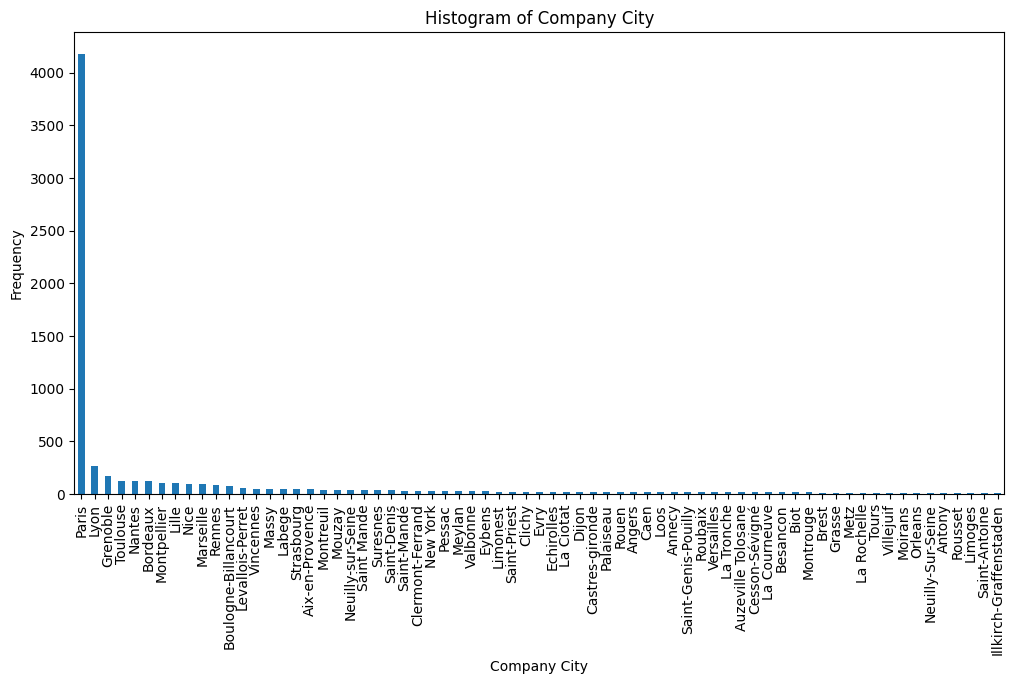

In [11]:
# Count the occurrences of each unique value in 'Company City'
company_city_counts = df['Company City'].value_counts()

# Plot the histogram
# Filter cities with more than 1 company
company_city_counts = company_city_counts[company_city_counts > 10]

# Plot the histogram
company_city_counts.plot(kind='bar', figsize=(12, 6))
plt.xlabel('Company City')
plt.ylabel('Frequency')
plt.title('Histogram of Company City')
plt.show()



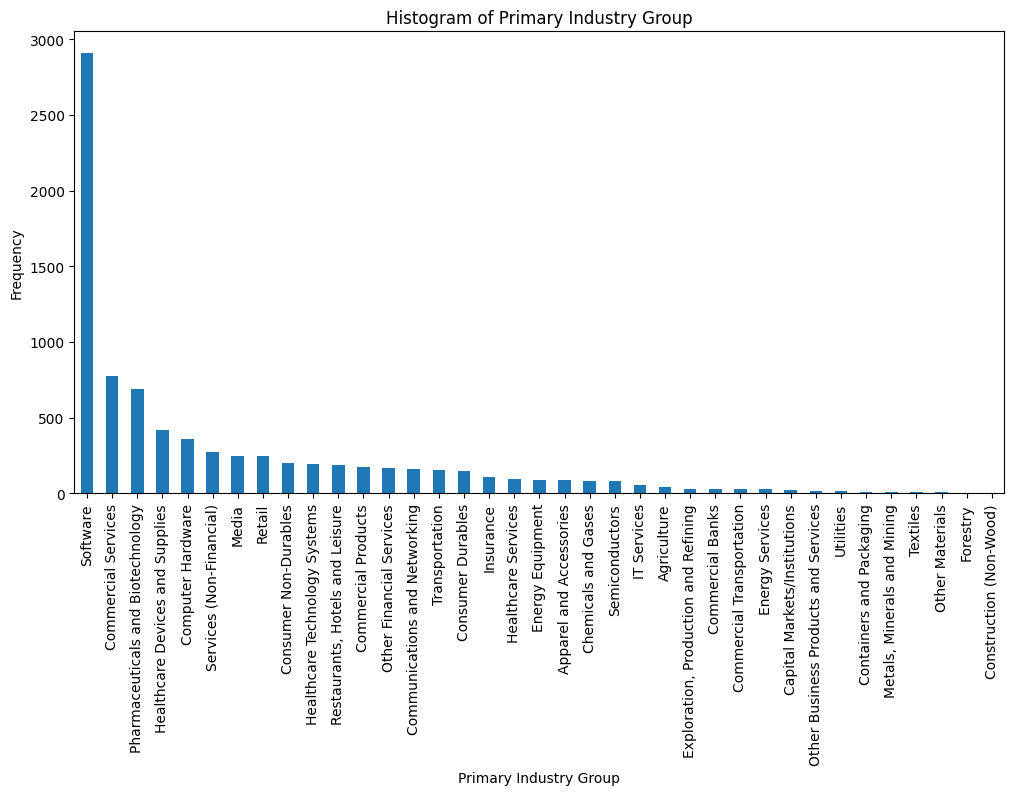

In [115]:
# Count the occurrences of each unique value in 'Primary Industry Group'
primary_industry_group_counts = df['Primary Industry Group'].value_counts()

# Plot the histogram
primary_industry_group_counts.plot(kind='bar', figsize=(12, 6))
plt.xlabel('Primary Industry Group')
plt.ylabel('Frequency')
plt.title('Histogram of Primary Industry Group')
plt.show()

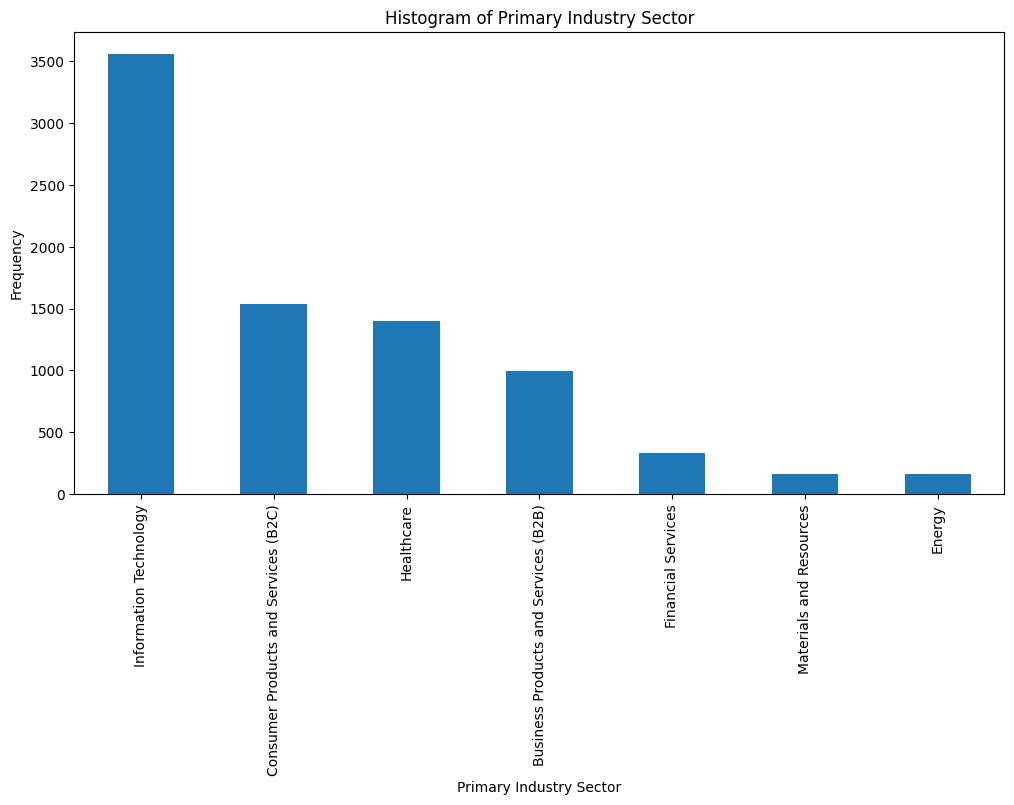

In [116]:
# Count the occurrences of each unique value in 'Primary Industry Sector'
primary_industry_sector_counts = df['Primary Industry Sector'].value_counts()

# Plot the histogram
primary_industry_sector_counts.plot(kind='bar', figsize=(12, 6))
plt.xlabel('Primary Industry Sector')
plt.ylabel('Frequency')
plt.title('Histogram of Primary Industry Sector')
plt.show()

C:\Users\juane\AppData\Local\Temp\ipykernel_21572\1637310855.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df['Total Deal Size (million, USD)'].resample('M').sum().plot(figsize=(12, 6))


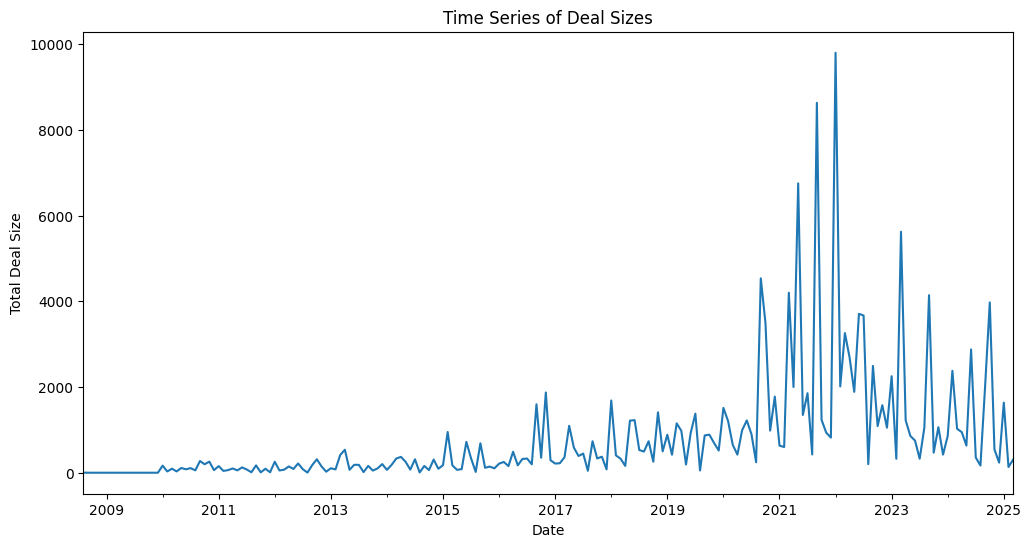

In [117]:
# Convert 'Deal Date' to datetime format
df['Deal Date'] = pd.to_datetime(df['Deal Date'])

# Set 'Deal Date' as the index
df.set_index('Deal Date', inplace=True)

# Plot the time series of deal dates
df['Total Deal Size (million, USD)'].resample('M').sum().plot(figsize=(12, 6))
plt.xlabel('Date')
plt.ylabel('Total Deal Size')
plt.title('Time Series of Deal Sizes')
plt.show()

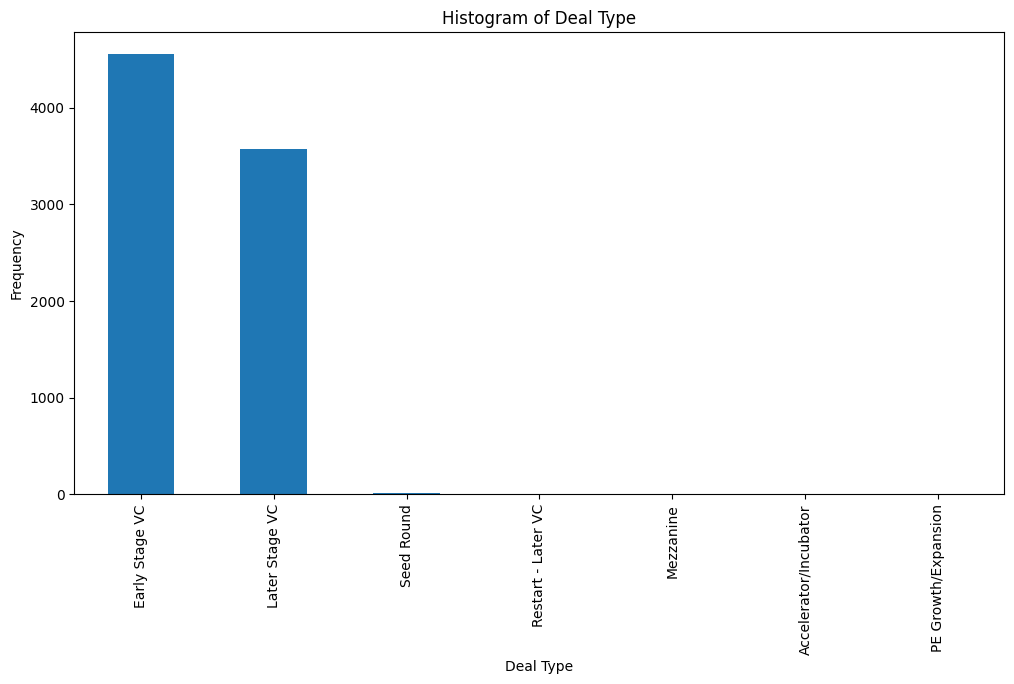

In [118]:
# Count the occurrences of each unique value in 'Deal Type'
deal_type_counts = df['Deal Type 1'].value_counts()

# Plot the histogram
deal_type_counts.plot(kind='bar', figsize=(12, 6))
plt.xlabel('Deal Type')
plt.ylabel('Frequency')
plt.title('Histogram of Deal Type')
plt.show()

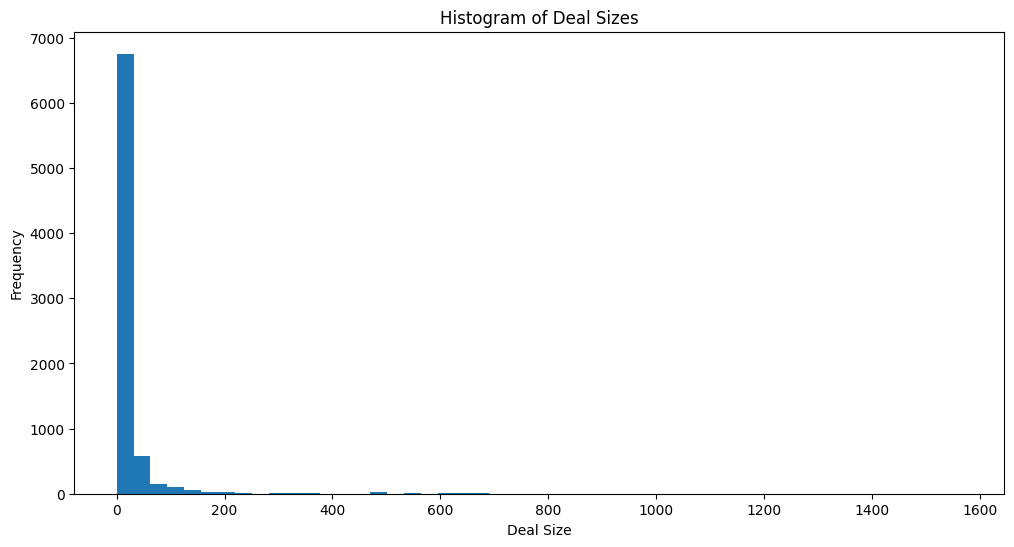

In [119]:
# Plot the histogram of deal sizes
df['Total Deal Size (million, USD)'].plot(kind='hist', bins=50, figsize=(12, 6))
plt.xlabel('Deal Size')
plt.ylabel('Frequency')
plt.title('Histogram of Deal Sizes')
plt.show()

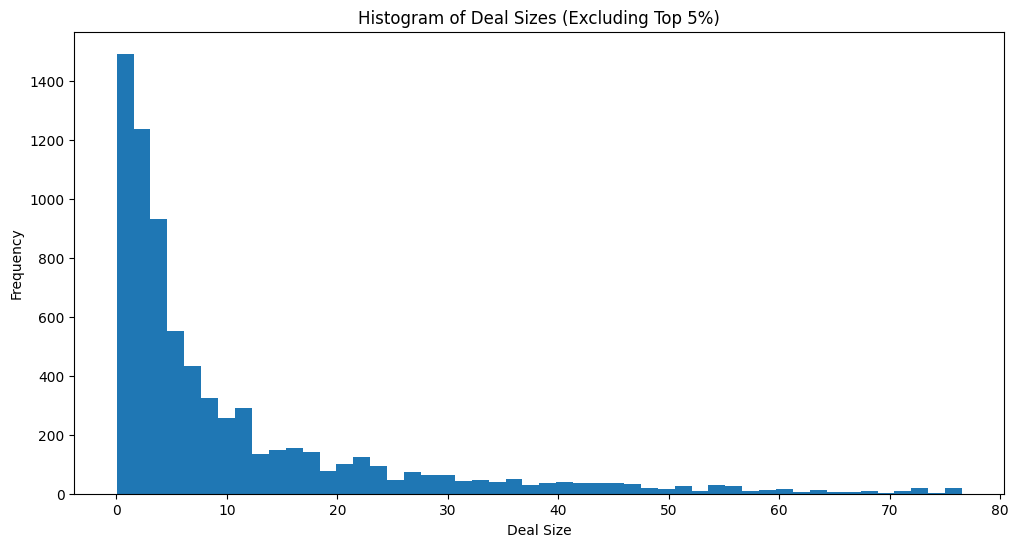

In [120]:
# Calculate the 99th percentile of deal sizes
percentile_95 = df['Total Deal Size (million, USD)'].quantile(0.95)

# Filter out the top 1% of deal sizes
filtered_deal_sizes = df[df['Total Deal Size (million, USD)'] <= percentile_95]['Total Deal Size (million, USD)']

# Plot the histogram of filtered deal sizes
filtered_deal_sizes.plot(kind='hist', bins=50, figsize=(12, 6))
plt.xlabel('Deal Size')
plt.ylabel('Frequency')
plt.title('Histogram of Deal Sizes (Excluding Top 5%)')
plt.show()

In [121]:
# Save the cleaned data to a new CSV file
df.to_csv('cleaned_data.csv', index=False)